# Features extracted from resnet18, PCA, fitting classifiers
On training set with removed backgrounds

Accuracy: not good

Imports

In [ ]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
import torch
import torch.nn as nn
from torchvision.models import resnet18
from tqdm import tqdm

import os

import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import numpy as np

Device selection

In [26]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CUDA GPU


Data prep

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Using images with no background

In [31]:
DATA_PATH = "/content/drive/MyDrive/aml-2025-feathers-in-focus"

TRAIN_CSV = os.path.join(DATA_DIR, "train_images.csv")
TRAIN_PATH = os.path.join(DATA_DIR, "train_images")
TEST_PATH  = os.path.join(DATA_DIR, "test_images")

print("training set:", TRAIN_PATH)
print("csv found", os.path.exists(TRAIN_CSV))
print("training set not empty", len(os.listdir(TRAIN_PATH)) > 0)

training set: /content/drive/MyDrive/aml-2025-feathers-in-focus/train_images
csv found True
training set not empty True


In [32]:
full_df = pd.read_csv(TRAIN_CSV)

#replacing with no background path
#full_df['image_path'] = full_df['image_path'].str.replace('/train_images/', '/train_images_rembg/', regex=False)
#full_df.to_csv('train_csv_rembg.csv')

print(full_df.head())
num_classes = full_df["label"].nunique()
print("Classes:", num_classes)

            image_path  label
0  /train_images/1.jpg      1
1  /train_images/2.jpg      1
2  /train_images/3.jpg      1
3  /train_images/4.jpg      1
4  /train_images/5.jpg      1
Classes: 200


In [33]:
class BirdDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.df['label'].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_rel = str(row["image_path"])
        filename = os.path.basename(img_rel)
        full_path = os.path.join(self.img_dir, filename)

        img = Image.open(full_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        label = self.class_to_idx[row["label"]]
        return img, label


In [34]:
train_df, val_df = train_test_split(full_df, test_size=0.2, random_state=42, stratify=full_df['label'])

In [35]:
BATCH_SIZE = 64
#big bc more efficient on GPU

Data augmentation

In [42]:
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(50),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_dataset = BirdDataset(train_df, TRAIN_PATH, transform=train_tfms)
val_dataset   = BirdDataset(val_df,   TRAIN_PATH, transform=test_tfms)

# num_workers, pin_memory and persistent_workers are set bc notebook was run on Cuda

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory = True, persistent_workers = True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory = True, persistent_workers = True)

In [43]:
classes = train_df['label'].unique()
classes

array([ 42, 193,  23,  49,  85,   5,  69, 179,  60,  56,  20,  12,  67,
        65,  84,  70, 186,  38,  21, 124,  17,  86, 147,  33,  77,  68,
       187,   6,  87,  61,  30, 199,  99,  31,  94,  45, 136, 146, 118,
        72,  14, 113,  59, 108, 126,   1, 200, 181, 166,  53, 185,  22,
        62,  16,  48, 172,  15, 125,  75, 140, 153, 133, 103,   9, 112,
       127, 131,  95,  13, 145,   7, 139, 101,  78,  88, 100,  11,  32,
        10,  35,  50, 169,  34, 178, 157, 142,  76,  58,  63,  93,  52,
         2,   3,  74, 110, 141,  64,  29, 120,  46,  97,  83,  57,  39,
        36,  40, 190, 188,  80, 130, 128, 105, 107,  71, 135,  91, 159,
        92,   4, 161, 163, 122,  47,   8,  43,  96,  25, 170,  79, 175,
        73,  19, 121, 149, 137,  44, 150,  55, 111, 194, 114,  90, 115,
        51,  89, 154, 152, 148, 155, 104, 123,  27, 109, 134,  24,  81,
       177,  26, 174, 164,  41,  54, 167, 184,  28, 158, 132, 119, 156,
       195,  66, 162,  18, 173, 117, 182, 160,  37, 191, 143, 19

feature extract resnet

In [44]:
class ResNet18Features(nn.Module):
    def __init__(self, weights=None):
        super().__init__()
        base = resnet18(weights=weights)
        self.features = nn.Sequential(*list(base.children())[:-1])

    def forward(self, x):
        x = self.features(x)
        return torch.flatten(x, 1)

In [45]:
num_classes = 200
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet18Features().to(device)

In [47]:
model = ResNet18Features(weights=None).to(device)

model.eval()

all_feats = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(train_loader, desc="Extracting features"):
        images = images.to(device)
        feats = model(images)
        all_feats.append(feats.cpu())
        all_labels.append(labels)

Extracting features: 100%|██████████| 50/50 [15:04<00:00, 18.08s/it]


In [52]:
X = torch.cat(all_feats).numpy()
y = torch.cat(all_labels).numpy()

np.save("bird_features.npy", X)
np.save("bird_labels.npy", y)

# Classification

In [53]:
X = np.load("bird_features.npy")  # shape (n_samples, n_features)
y = np.load("bird_labels.npy")    # shape (n_samples,)

Train test split

In [54]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
print(X_train.shape, X_val.shape)

(2669, 512) (471, 512)


Standardizing

In [57]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

PCA

In [58]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print("train pca shape", X_train_pca.shape)
print("val pca shape", X_val_pca.shape)

train pca shape (2669, 103)
val pca shape (471, 103)


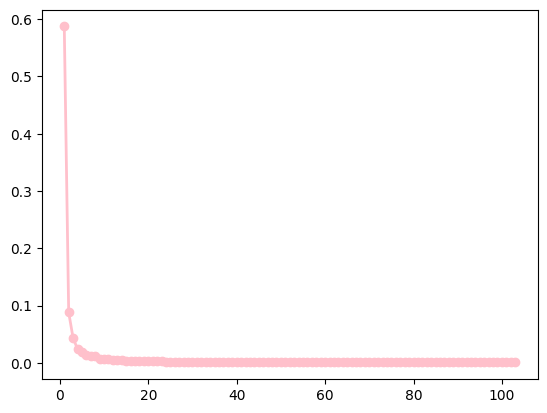

In [59]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='pink')
plt.show()

Clearly only the first ~10 components are useful in this case

In [ ]:
def train_eval_xgb(params, verbose=False):
    clf = XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        use_label_encoder=False,
        device='cuda',
        **params,
    )

    clf.fit(
        X_train_pca, y_train,
        eval_set=[(X_val_pca, y_val)],
        verbose=verbose,
    )

    y_pred = clf.predict(X_val_pca)
    acc = accuracy_score(y_val, y_pred)
    return acc, clf

In [ ]:
baseline_params = {
    "n_estimators": 200,
    "max_depth": 4,
    "learning_rate": 0.1,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "n_jobs": -1,
}

print("\n=== Baseline XGBoost (single run) ===")
baseline_acc, baseline_model = train_eval_xgb(baseline_params, verbose=False)
print(f"Baseline val accuracy: {baseline_acc:.4f}")

y_pred_baseline = baseline_model.predict(X_val_pca)
print("\nClassification report (baseline):\n")
print(classification_report(y_val, y_pred_baseline))

print("Confusion matrix (baseline):\n", confusion_matrix(y_val, y_pred_baseline))


# ============================================

In [ ]:
print("\n=== Manual hyperparameter search (small grid, single split) ===")

param_grid = {
    "max_depth":    [5, 10],
    "learning_rate": [0.1, 0.15],
    "subsample":    [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

results = []
best_acc = -1
best_params = None
best_model = None

for max_depth in param_grid["max_depth"]:
    for lr in param_grid["learning_rate"]:
        for subsample in param_grid["subsample"]:
            for colsample in param_grid["colsample_bytree"]:
                params = {
                    "n_estimators": 300,  # slightly higher, early stopping will cut it
                    "max_depth": max_depth,
                    "learning_rate": lr,
                    "subsample": subsample,
                    "colsample_bytree": colsample,
                    "n_jobs": -1,
                }
                acc, model = train_eval_xgb(params, verbose=False)
                results.append((acc, params))

                print(f"val_acc={acc:.4f} | depth={max_depth}, lr={lr}, sub={subsample}, col={colsample}")

                if acc > best_acc:
                    best_acc = acc
                    print('Best accuracy:', best_acc)
                    best_params = params
                    best_model = model

print("\n=== Best config (manual search) ===")
print("Best val accuracy:", best_acc)
print("Best params:", best_params)

In [ ]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_val)
acc = accuracy_score(y_val, y_pred)

print("Validation accuracy:", acc)
print("\nClassification report:\n", classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
print("\nConfusion matrix:\n", cm)

In [ ]:
y_proba = best_model.predict_proba(X_val)  # shape (n_samples, n_classes)

In [ ]:
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        max_iter=500,
        class_weight="balanced"
    )),
])

logreg_params = {
    "pca__n_components": [0.80, 0.90, 0.95, 0.99],
    "clf__C": [0.01, 0.1, 1, 10],
}

logreg_search = RandomizedSearchCV(
    logreg_pipe,
    param_distributions=logreg_params,
    n_iter=10,
    scoring="accuracy",
    n_jobs=-1,
    cv=cv,
    random_state=42,
)

logreg_search.fit(X_train, y_train)
print("LogReg best acc:", logreg_search.best_score_)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipe = Pipeline([
    ("clf", RandomForestClassifier(class_weight="balanced", n_estimators=300)),
])

rf_params = {
    "pca__n_components": [0.80, 0.90, 0.95],
    "clf__max_depth": [None, 10, 20, 40],
    "clf__min_samples_split": [2, 5, 10],
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_params,
    n_iter=12,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
)

rf_search.fit(X_train, y_train)
print("RF best acc:", rf_search.best_score_)

In [ ]:
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",      # <-- use GPU
    predictor="predictor",   # <-- GPU inference
    n_estimators=200,            # not too large to keep it fast
    max_depth=4,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    device='cuda',
    n_jobs=1, # let sklearn handle parallelism
)


pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),  # keep 95% variance
    ("clf", xgb_clf),
])


# ============================================
# 6. Quick baseline fit (no CV, just to see it works)
# ============================================
print("\n=== Fitting simple XGB pipeline (no CV) ===")
pipe.fit(X_train, y_train)

y_pred_val = pipe.predict(X_val)
acc_val = accuracy_score(y_val, y_pred_val)

print(f"Validation accuracy (simple XGB): {acc_val:.4f}")
print("\nClassification report:\n", classification_report(y_val, y_pred_val))

cm = confusion_matrix(y_val, y_pred_val)
print("\nConfusion matrix:\n", cm)

In [ ]:
use_hyperparam_search = True  # set to False if you only want the simple model

if use_hyperparam_search:
    print("\n=== Starting lightweight RandomizedSearchCV for XGB ===")

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    param_dist = {
        "pca__n_components": [0.90, 0.95],      # try 90% vs 95% variance
        "clf__max_depth": [3, 4, 5],
        "clf__learning_rate": [0.05, 0.1],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
        "clf__n_estimators": [100, 200],       # smaller range to keep it fast
    }

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=8,             # only 8 combos → manageable
        scoring="accuracy",
        n_jobs=-1,            # parallel over folds and configs
        cv=cv,
        verbose=2,
        random_state=42,
    )

    search.fit(X_train, y_train)

    print("\nBest CV accuracy:", search.best_score_)
    print("Best params:", search.best_params_)

    # Evaluate best model on validation set
    best_model = search.best_estimator_
    y_pred_best = best_model.predict(X_val)
    best_acc = accuracy_score(y_val, y_pred_best)

    print(f"\nValidation accuracy (best XGB from search): {best_acc:.4f}")
    print("\nClassification report (best model):\n", classification_report(y_val, y_pred_best))

    cm_best = confusion_matrix(y_val, y_pred_best)
    print("\nConfusion matrix (best model):\n", cm_best)

    # You can keep the best model for later use:
    # import joblib
    # joblib.dump(best_model, "xgb_pca_pipeline.joblib")